#Setup

In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

project_id = "walmart-demand-intelligence"
client     = bigquery.Client(project=project_id)

plt.style.use('seaborn-v0_8')
print("Connected!")

Connected!


In [ ]:
# Pull a sample — full 59M rows too large for local memory
# Use one store + one category for EDA
df = client.query("""
    SELECT
        item_id,
        store_id,
        dept_id,
        day_id,
        day_num,
        category,
        department,
        state,
        store_number,
        calendar_date,
        sales,
        is_no_sales,
        weekday_name,
        weekday_num,
        month,
        year,
        quarter,
        is_weekend,
        is_holiday_season,
        is_summer,
        is_winter,
        is_event,
        is_Thanksgiving,
        is_Christmas,
        is_snap_day,
        sell_price,
        is_on_promotion,
        avg_price_rolling_4wk,
        lag_7,
        rolling_mean_7,
        rolling_mean_28,
        rolling_std_7,
        no_sales_last_7_days,
    FROM `walmart_forecasting.mart_forecast_input`
    WHERE store_id = 'CA_1'
    AND calendar_date IS NOT NULL
    ORDER BY item_id, day_num
""").to_dataframe()

print(f"Rows:       {len(df):,}")
print(f"Items:      {df['item_id'].nunique():,}")
print(f"Columns:    {len(df.columns)}")
print(f"Date range: {df['calendar_date'].min()} → {df['calendar_date'].max()}")
df.head()

/Users/maytilok/dbt-env/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Rows:       5,918,109
Items:      3,049
Columns:    33
Date range: 2011-01-29 → 2016-05-22


,item_id,store_id,dept_id,day_id,day_num,category,department,state,store_number,calendar_date,...,is_Christmas,is_snap_day,sell_price,is_on_promotion,avg_price_rolling_4wk,lag_7,rolling_mean_7,rolling_mean_28,rolling_std_7,no_sales_last_7_days
0,FOODS_1_001,CA_1,FOODS_1,d_1,1,FOODS,1,CA,1,2011-01-29,...,0,0,2.0,0,2.0,<NA>,NaN,NaN,NaN,0
1,FOODS_1_001,CA_1,FOODS_1,d_2,2,FOODS,1,CA,1,2011-01-30,...,0,0,2.0,0,2.0,<NA>,3.0,3.0,NaN,0
2,FOODS_1_001,CA_1,FOODS_1,d_3,3,FOODS,1,CA,1,2011-01-31,...,0,0,2.0,0,2.0,<NA>,1.5,1.5,2.121320,1
3,FOODS_1_001,CA_1,FOODS_1,d_4,4,FOODS,1,CA,1,2011-02-01,...,0,1,2.0,0,2.0,<NA>,1.0,1.0,1.732051,2
4,FOODS_1_001,CA_1,FOODS_1,d_5,5,FOODS,1,CA,1,2011-02-02,...,0,1,2.0,0,2.0,<NA>,1.0,1.0,1.414214,2


## Duration

In [19]:
print(f"Start date:   {df['calendar_date'].min()}")
print(f"End date:   {df['calendar_date'].max()}")

Start date:   2011-01-29 00:00:00
End date:   2016-05-22 00:00:00


#Exploratory Data Analysis for store CA_1 from Jan 29th, 2011 to May 22nd, 2016

##Sales distributions

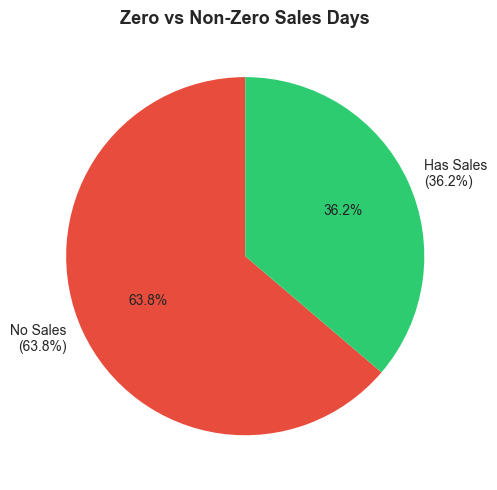

Average daily sales:  1.32 units
No sales days:        63.8%
Max daily sales:      648 units


In [18]:
plt.figure(figsize=(14, 5))

# Zero vs non-zero sales
zero_pct    = df['is_no_sales'].mean() * 100
nonzero_pct = 100 - zero_pct

plt.pie(
    [zero_pct, nonzero_pct],
    labels=[f'No Sales\n({zero_pct:.1f}%)',
            f'Has Sales\n({nonzero_pct:.1f}%)'],
    colors=['#e74c3c', '#2ecc71'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Zero vs Non-Zero Sales Days',
                   fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../dashboard/sales_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Average daily sales:  {df['sales'].mean():.2f} units")
print(f"No sales days:        {zero_pct:.1f}%")
print(f"Max daily sales:      {df['sales'].max()} units")

##Sales by category

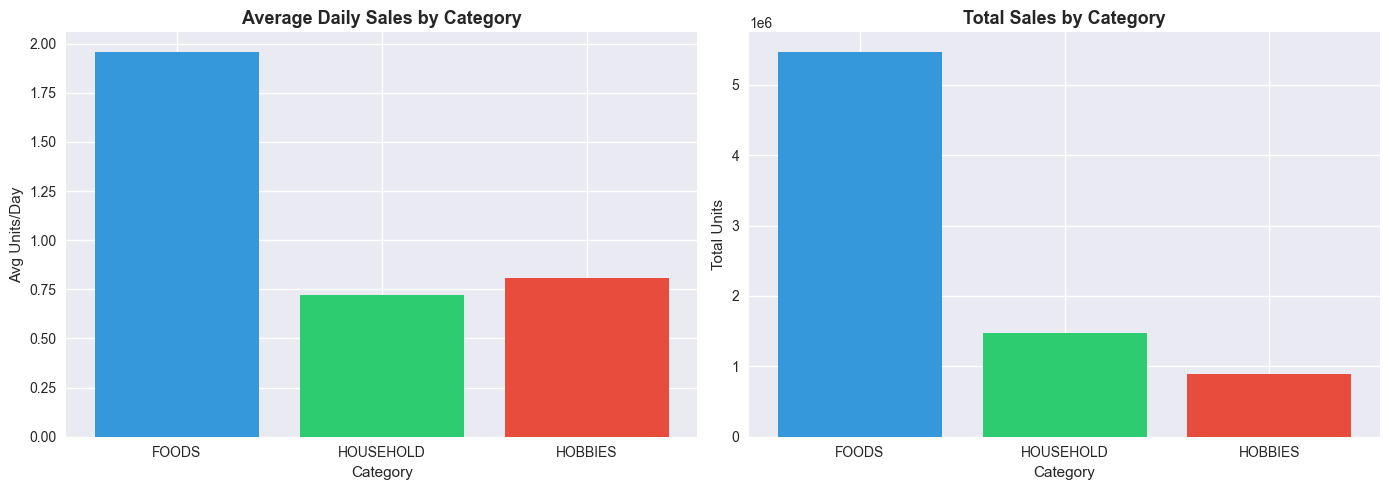

 category  avg_sales  total_sales  std_sales
    FOODS       1.96      5471661       5.38
HOUSEHOLD       0.72      1468504       1.65
  HOBBIES       0.81       892083       2.83


In [5]:
category_sales = (
    df.groupby('category')['sales']
    .agg(
        avg_sales  = 'mean',
        total_sales= 'sum',
        std_sales  = 'std'
    )
    .round(2)
    .sort_values('total_sales', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']

axes[0].bar(category_sales['category'],
            category_sales['avg_sales'],
            color=colors)
axes[0].set_title('Average Daily Sales by Category',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Avg Units/Day')

axes[1].bar(category_sales['category'],
            category_sales['total_sales'],
            color=colors)
axes[1].set_title('Total Sales by Category',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total Units')

plt.tight_layout()
plt.savefig('../dashboard/category_sales.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(category_sales.to_string(index=False))

##Monthly sales trend

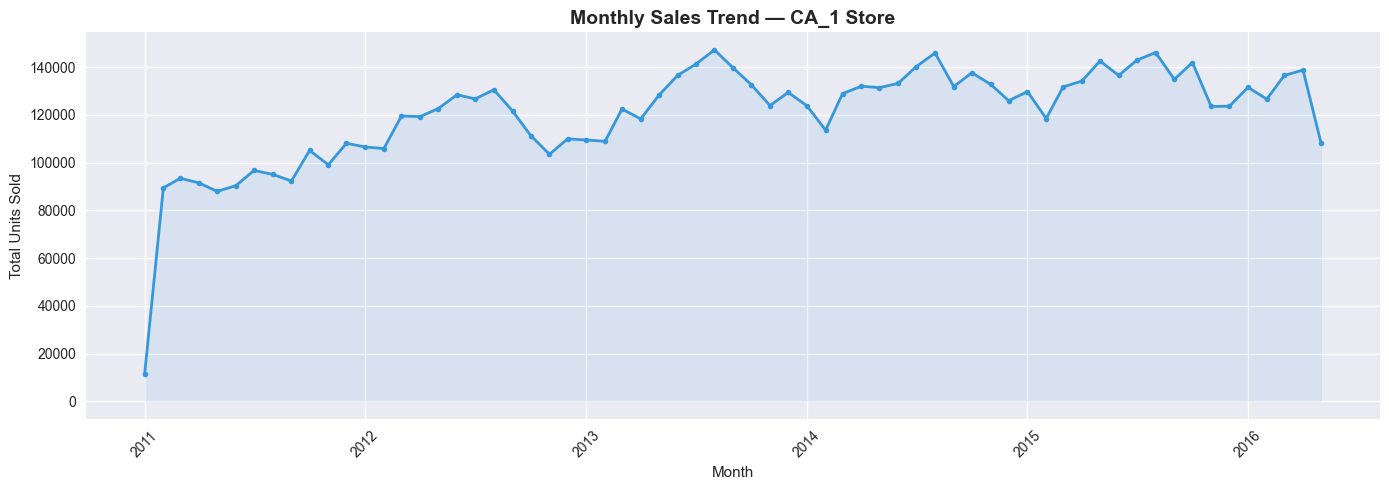

Peak month:   Aug 2013
Peak sales:   147,275 units
Lowest month: Jan 2011


In [7]:
df['calendar_date'] = pd.to_datetime(df['calendar_date'])

monthly = (
    df.groupby([df['calendar_date'].dt.to_period('M')])['sales']
    .sum()
    .reset_index()
)
monthly['calendar_date'] = monthly['calendar_date'].dt.to_timestamp()

plt.figure(figsize=(14, 5))
plt.plot(monthly['calendar_date'], monthly['sales'],
         marker='o', linewidth=2, color='#3498db', markersize=4)
plt.fill_between(monthly['calendar_date'], monthly['sales'],
                  alpha=0.1, color='#3498db')
plt.title('Monthly Sales Trend — CA_1 Store',
           fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../dashboard/monthly_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak month:   {monthly.loc[monthly['sales'].idxmax(), 'calendar_date'].strftime('%b %Y')}")
print(f"Peak sales:   {monthly['sales'].max():,} units")
print(f"Lowest month: {monthly.loc[monthly['sales'].idxmin(), 'calendar_date'].strftime('%b %Y')}")

##Day of week pattern

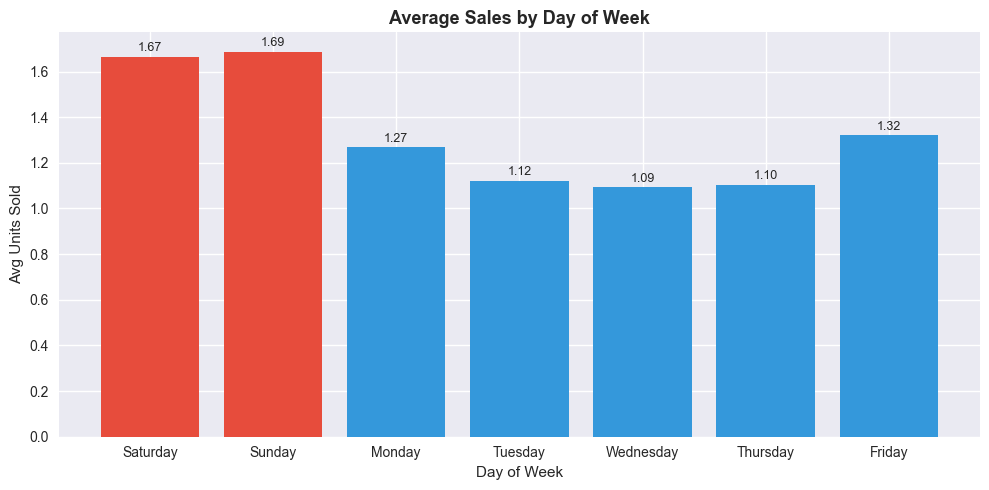

In [8]:
day_order = ['Saturday', 'Sunday', 'Monday',
             'Tuesday', 'Wednesday', 'Thursday', 'Friday']

dow_sales = (
    df.groupby('weekday_name')['sales']
    .mean()
    .reset_index()
)
dow_sales['weekday_name'] = pd.Categorical(
    dow_sales['weekday_name'],
    categories=day_order,
    ordered=True
)
dow_sales = dow_sales.sort_values('weekday_name')

plt.figure(figsize=(10, 5))
bars = plt.bar(
    dow_sales['weekday_name'],
    dow_sales['sales'],
    color=['#e74c3c' if d in ['Saturday', 'Sunday']
           else '#3498db' for d in dow_sales['weekday_name']]
)
plt.title('Average Sales by Day of Week',
           fontsize=13, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Avg Units Sold')

for bar, val in zip(bars, dow_sales['sales']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../dashboard/dow_pattern.png',
            dpi=150, bbox_inches='tight')
plt.show()

##Holiday impact

Event Impact on Sales:
   is_event  mean   count
Regular Day  1.33 5436367
  Event Day  1.25  481742


Event day sales lift: -6.0%


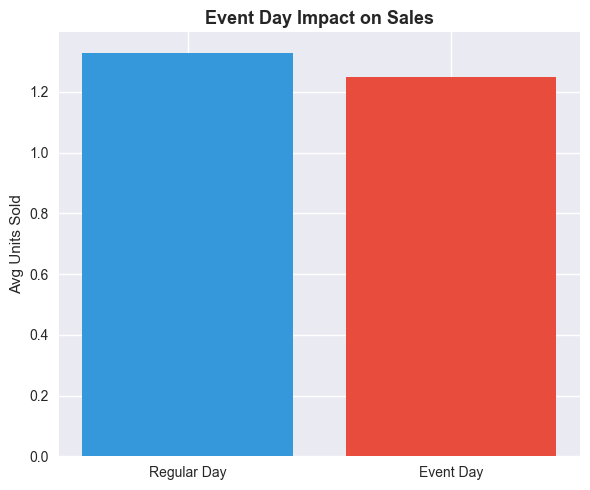

In [22]:
holiday_impact = (
    df.groupby('is_event')['sales']
    .agg(['mean', 'count'])
    .round(2)
    .reset_index()
)
holiday_impact['is_event'] = holiday_impact['is_event'].map(
    {0: 'Regular Day', 1: 'Event Day'}
)

print("Event Impact on Sales:")
print(holiday_impact.to_string(index=False))
print()

regular = holiday_impact[holiday_impact['is_event']=='Regular Day']['mean'].values[0]
event    = holiday_impact[holiday_impact['is_event']=='Event Day']['mean'].values[0]
lift    = (event / regular - 1) * 100

print(f"\nEvent day sales lift: {lift:+.1f}%")

plt.figure(figsize=(6, 5))
plt.bar(['Regular Day', 'Event Day'], [regular, event],
        color=['#3498db', '#e74c3c'])
plt.title('Event Day Impact on Sales',
           fontsize=13, fontweight='bold')
plt.ylabel('Avg Units Sold')
plt.tight_layout()
plt.savefig('../dashboard/event_impact.png',
            dpi=150, bbox_inches='tight')
plt.show()


##SNAP day impact

SNAP Day Impact:
is_snap_day  mean   count
Regular Day  1.28 3966749
   SNAP Day  1.41 1951360

SNAP day sales lift: +10.2%


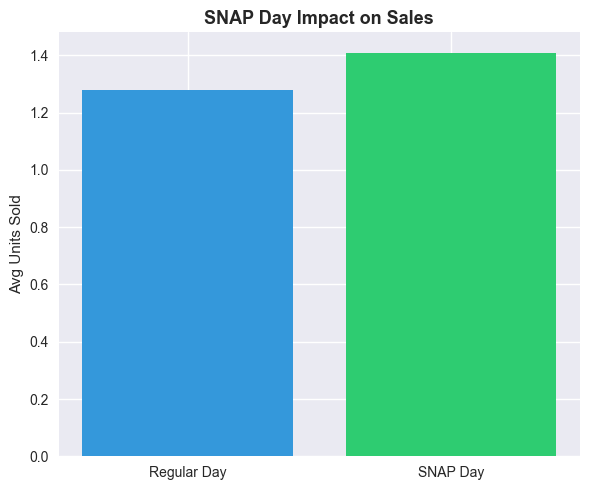

In [11]:
snap_impact = (
    df.groupby('is_snap_day')['sales']
    .agg(['mean', 'count'])
    .round(2)
    .reset_index()
)
snap_impact['is_snap_day'] = snap_impact['is_snap_day'].map(
    {0: 'Regular Day', 1: 'SNAP Day'}
)

print("SNAP Day Impact:")
print(snap_impact.to_string(index=False))

regular = snap_impact[snap_impact['is_snap_day']=='Regular Day']['mean'].values[0]
snap    = snap_impact[snap_impact['is_snap_day']=='SNAP Day']['mean'].values[0]
lift    = (snap / regular - 1) * 100

print(f"\nSNAP day sales lift: {lift:+.1f}%")

plt.figure(figsize=(6, 5))
plt.bar(['Regular Day', 'SNAP Day'], [regular, snap],
        color=['#3498db', '#2ecc71'])
plt.title('SNAP Day Impact on Sales',
           fontsize=13, fontweight='bold')
plt.ylabel('Avg Units Sold')
plt.tight_layout()
plt.savefig('../dashboard/snap_impact.png',
            dpi=150, bbox_inches='tight')
plt.show()

##Price vs sales

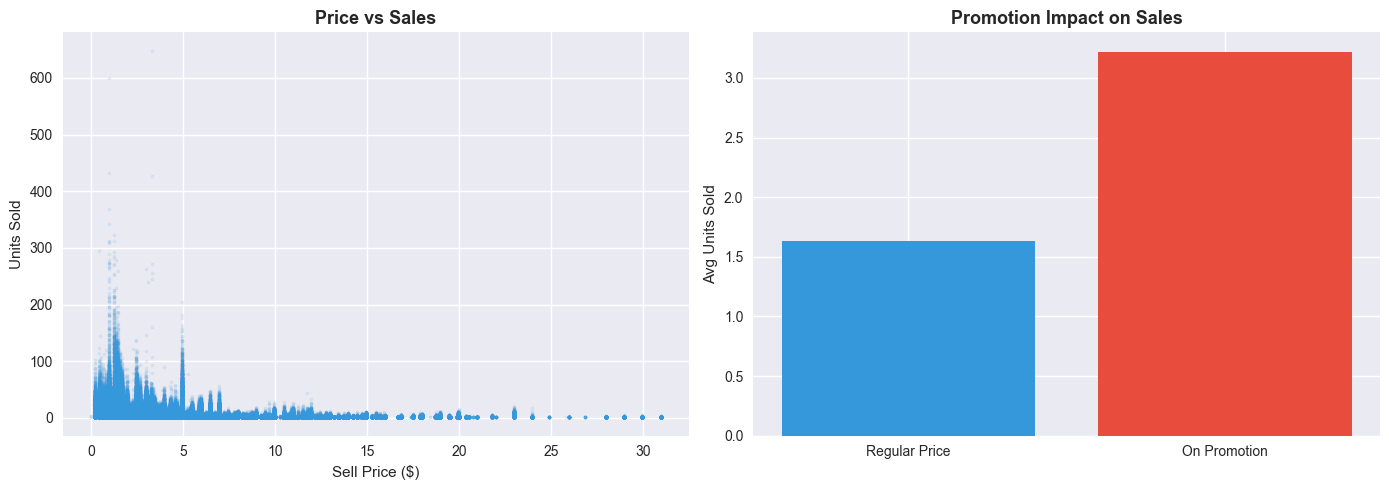

Price-Sales correlation: -0.189


In [12]:
df_price = df[
    (df['sales'] > 0) &
    (df['sell_price'].notna())
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_price['sell_price'], df_price['sales'],
                alpha=0.1, s=5, color='#3498db')
axes[0].set_title('Price vs Sales',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sell Price ($)')
axes[0].set_ylabel('Units Sold')

# Promotion impact
promo_sales = (
    df.groupby('is_on_promotion')['sales']
    .mean()
    .reset_index()
)
promo_sales['is_on_promotion'] = promo_sales['is_on_promotion'].map(
    {0: 'Regular Price', 1: 'On Promotion'}
)
axes[1].bar(promo_sales['is_on_promotion'],
            promo_sales['sales'],
            color=['#3498db', '#e74c3c'])
axes[1].set_title('Promotion Impact on Sales',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Units Sold')

plt.tight_layout()
plt.savefig('../dashboard/price_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

correlation = df_price['sell_price'].corr(df_price['sales'])
print(f"Price-Sales correlation: {correlation:.3f}")